# Implementation of BiLSTM for raw features

### Check that GPU is running

In [1]:
from tensorflow.python.client import device_lib
print("\n".join([x.name for x in device_lib.list_local_devices()]))

/device:CPU:0
/device:GPU:0


## Load required libraries

In [1]:
import random, numpy as np, tensorflow as tf
import os
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout, Masking, Input, GlobalMaxPooling1D
from tensorflow.keras.optimizers import Adam
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
import random
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Set global seed to control randomness

In [2]:
pi_digit_string = "1415926535897932384626433832795028841971"
seeds= [int(pi_digit_string[i:i+2]) for i in range(0, len(pi_digit_string), 2)]
print(len(seeds), seeds)

def set_seed(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

# Set the seed for reproducibility
set_seed(seeds[0])

# Set the random seed for TensorFlow operations
tf.config.experimental.enable_op_determinism()

20 [14, 15, 92, 65, 35, 89, 79, 32, 38, 46, 26, 43, 38, 32, 79, 50, 28, 84, 19, 71]


# Preprocessing

In [12]:
data = np.load("../preprocessing/ready/squat_sequences_all_features_normalized.npz")

X_data = data["X"]
X_data = X_data[:, :, 1:-6] # remove the first 1 and last 6 features (frames and angles)
y_labels = data["y"]


X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_labels, test_size=0.2, stratify=y_labels, random_state=seeds[0]
)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)
print(X_train[0].shape, X_test[0].shape, y_train[0], y_test[0])

print(y_test)

print("X_train:", X_train.shape, X_train.dtype)
print("y_train:", y_train.shape, y_train.dtype)


(201, 189, 30) (51, 189, 30) (201,) (51,)
(189, 30) (189, 30) 1 0
[0 1 1 1 0 0 0 1 0 0 1 1 0 1 1 0 1 0 1 0 0 1 0 1 1 1 0 0 1 1 1 1 0 0 1 0 0
 0 0 0 1 0 0 1 1 1 0 1 1 0 0]
X_train: (201, 189, 30) float32
y_train: (201,) int32


# Preprocessing with Augmented Training set

In [3]:
import sys
sys.path.append("../preprocessing/Augmented_LSTM")
from augmenter import Augmenter

# Load preprocessed augmented train/test sets
data = np.load("../preprocessing/ready/squat_sequences_all_features_normalized.npz")
X_data = data["X"]
X_data = X_data[:, :, 1:-6] # remove the first 1 and last 6 features (frames and angles)
y_labels = data["y"]

X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_labels, test_size=0.2, stratify=y_labels, random_state=seeds[0]
)

# Use the augmenter class
augmenter = Augmenter(noise_std=0.05, noise_n=2, mirror=False)
X_train, y_train = augmenter.augment(X_train, y_train, base_seed=seeds[0])

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)
print(X_train[0].shape, X_test[0].shape, y_train[0], y_test[0])

print(y_test)

(603, 189, 30) (51, 189, 30) (603,) (51,)
(189, 30) (189, 30) 1 0
[0 1 1 1 0 0 0 1 0 0 1 1 0 1 1 0 1 0 1 0 0 1 0 1 1 1 0 0 1 1 1 1 0 0 1 0 0
 0 0 0 1 0 0 1 1 1 0 1 1 0 0]


# Defined model Function

In [4]:

def make_model_builder(input_shape):
    def build_model(lstm_units=64, dropout_rate=0.2, learning_rate=0.001):
        model = Sequential([
            Input(shape=input_shape),
            Masking(mask_value=0.0),
            Bidirectional(LSTM(lstm_units, return_sequences=True)),
            GlobalMaxPooling1D(),
            Dropout(dropout_rate),
            Dense(1, activation="sigmoid")
        ])
        model.compile(optimizer=Adam(learning_rate), loss="binary_crossentropy", metrics=["accuracy"])
        return model
    return build_model

# Grid search with 5-fold cross validation

In [11]:
# Create the model builder using your actual input shape
model_builder = make_model_builder(input_shape=(X_train.shape[1], X_train.shape[2]))

# Wrap for sklearn compatibility
bilstm_clf = KerasClassifier(
    model=model_builder,
    batch_size=32,  # fixed based on good past results
    verbose=1       # silent training
)

# Define hyperparameter grid, now including epochs too!
param_grid = {
    "model__lstm_units": [64, 96, 128],
    "model__dropout_rate": [0.2, 0.3, 0.4],
    "model__learning_rate": [0.0003, 0.0005],
    "epochs": [50, 100, 150]
}

# 5-fold Stratified Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seeds[0])

# Grid search setup
grid_search = GridSearchCV(
    estimator=bilstm_clf,
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=2,   # Set to -1 for full parallelization if your CPU allows
    verbose=1
)

# Run the grid search
grid_search.fit(X_train, y_train)

# Print best results
print(f"\n✅ Best Parameters: {grid_search.best_params_}")
print(f"✅ Best Cross-Validated Accuracy: {grid_search.best_score_:.4f}")

# View top results
results_df = pd.DataFrame(grid_search.cv_results_).sort_values(by="mean_test_score", ascending=False)
print(results_df[["mean_test_score", "std_test_score", "params"]].head())

Fitting 5 folds for each of 54 candidates, totalling 270 fits


KeyboardInterrupt: 

# Train the final model with the best hyperparameters

In [34]:
# Get the best model from the grid search
fixed_config = {
    "lstm_units": 64,
    "dropout_rate": 0.2,
    "learning_rate": 0.0005,
    "batch_size": 32,
    "epochs": 100
}


# Create builder with correct input shape
model_builder = make_model_builder(input_shape=(X_train.shape[1], X_train.shape[2]))

# Call the returned function with best params
final_model = model_builder(
    lstm_units=fixed_config["lstm_units"],
    dropout_rate=fixed_config["dropout_rate"],
    learning_rate=fixed_config["learning_rate"]
)


# Train on the entire training set with the best params.
history = final_model.fit(
    X_train, y_train,
    epochs=fixed_config["epochs"],
    batch_size=fixed_config["batch_size"],
    verbose=1
)

# Evaluate on held-out test set
test_loss, test_accuracy = final_model.evaluate(X_test, y_test, verbose=0)
print(f"\n✅ Final test accuracy: {test_accuracy:.4f}")

Epoch 1/100
7/7 [==============================] - 12s 55ms/step - loss: 0.6850 - accuracy: 0.5274
Epoch 2/100
7/7 [==============================] - 0s 31ms/step - loss: 0.6571 - accuracy: 0.6418
Epoch 3/100
7/7 [==============================] - 0s 29ms/step - loss: 0.6512 - accuracy: 0.6915
Epoch 4/100
7/7 [==============================] - 0s 30ms/step - loss: 0.6355 - accuracy: 0.7313
Epoch 5/100
7/7 [==============================] - 0s 29ms/step - loss: 0.5898 - accuracy: 0.8259
Epoch 6/100
7/7 [==============================] - 0s 29ms/step - loss: 0.5765 - accuracy: 0.8458
Epoch 7/100
7/7 [==============================] - 0s 27ms/step - loss: 0.5417 - accuracy: 0.8806
Epoch 8/100
7/7 [==============================] - 0s 29ms/step - loss: 0.4997 - accuracy: 0.8657
Epoch 9/100
7/7 [==============================] - 0s 32ms/step - loss: 0.4472 - accuracy: 0.9104
Epoch 10/100
7/7 [==============================] - 0s 29ms/step - loss: 0.3917 - accuracy: 0.9204
Epoch 11/100
7/7 [

# Save the model for reproducability

In [35]:
final_model.save("trained_models/bilstm_model_raw.h5")
print("Model saved as bilstm_model_raw.h5")

Model saved as bilstm_model_raw.h5


# Evaluation

In [5]:
from collections import defaultdict
from tensorflow.keras.models import load_model

# Store metrics
results = defaultdict(list)

# Evaluate on test sets created with different seeds
for seed in seeds:
    print(f"\n Evaluating with test split from seed {seed}")
    set_seed(seed)

    # Resplit to get test set (ignore training part)
    X_train, X_test, y_train, y_test = train_test_split(
        X_data, y_labels, test_size=0.2, stratify=y_labels, random_state=seed
    )

    # Use the augmenter class
    augmenter = Augmenter(noise_std=0.05, noise_n=2, mirror=False)
    X_train, y_train = augmenter.augment(X_train, y_train, base_seed=seed)

    # Manually define a config you want to test
    fixed_config = {
        "lstm_units": 96,
        "dropout_rate": 0.3,
        "learning_rate": 0.0003,
        "epochs": 50,
        "batch_size": 32
    }

    # Create builder with correct input shape
    model_builder = make_model_builder(input_shape=(X_train.shape[1], X_train.shape[2]))

    # Call the returned function with best params
    final_model = model_builder(
        lstm_units=fixed_config["lstm_units"],
        dropout_rate=fixed_config["dropout_rate"],
        learning_rate=fixed_config["learning_rate"]
    )


    # Train on the entire training set with the best params.
    history = final_model.fit(
        X_train, y_train,
        epochs=fixed_config["epochs"],
        batch_size=fixed_config["batch_size"],
        verbose=1
    )
    
    # Predict and evaluate
    y_pred_probs = final_model.predict(X_test).flatten()
    y_pred = (y_pred_probs > 0.5).astype("int")

    report = classification_report(y_test, y_pred, output_dict=True)
    cm = confusion_matrix(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_probs)

    # Store key metrics
    results["accuracy"].append(report["accuracy"])
    results["precision"].append(report["1"]["precision"])
    results["recall"].append(report["1"]["recall"])
    results["f1"].append(report["1"]["f1-score"])
    results["roc_auc"].append(roc_auc)

    # Store confusion matrix components
    results["tp"].append(cm[1, 1])
    results["fn"].append(cm[1, 0])
    results["fp"].append(cm[0, 1])
    results["tn"].append(cm[0, 0])


# Print summary
print("\n Final evaluation over multiple test splits:")
for metric in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    values = results[metric]
    print(f"{metric.capitalize():<10}: {np.mean(values):.4f} ± {np.std(values):.4f}")

# Print confusion matrix components
# Average confusion matrix
avg_cm = np.array([
    [np.mean(results["tn"]), np.mean(results["fp"])],
    [np.mean(results["fn"]), np.mean(results["tp"])]
]).round().astype(int)

print("\n Mean Confusion Matrix (rounded):")
print(avg_cm)



 Evaluating with test split from seed 14
Epoch 1/50
19/19 [==============================] - 11s 34ms/step - loss: 0.6804 - accuracy: 0.5556
Epoch 2/50
19/19 [==============================] - 1s 37ms/step - loss: 0.6353 - accuracy: 0.7214
Epoch 3/50
19/19 [==============================] - 1s 33ms/step - loss: 0.5717 - accuracy: 0.8491
Epoch 4/50
19/19 [==============================] - 1s 33ms/step - loss: 0.4611 - accuracy: 0.9038
Epoch 5/50
19/19 [==============================] - 1s 33ms/step - loss: 0.3129 - accuracy: 0.8972
Epoch 6/50
19/19 [==============================] - 1s 33ms/step - loss: 0.2344 - accuracy: 0.9005
Epoch 7/50
19/19 [==============================] - 1s 32ms/step - loss: 0.1701 - accuracy: 0.9602
Epoch 8/50
19/19 [==============================] - 1s 33ms/step - loss: 0.1460 - accuracy: 0.9569
Epoch 9/50
19/19 [==============================] - 1s 34ms/step - loss: 0.1319 - accuracy: 0.9602
Epoch 10/50
19/19 [==============================] - 1s 34ms/step 

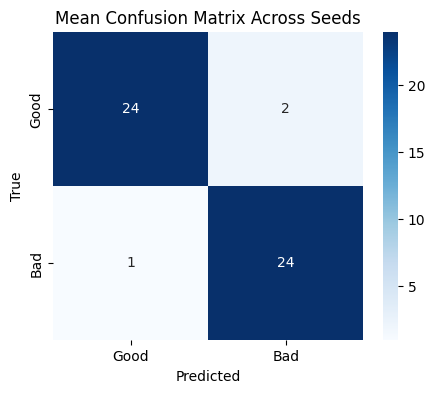

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 4))
sns.heatmap(avg_cm, annot=True, fmt="d", cmap="Blues")
plt.title("Mean Confusion Matrix Across Seeds")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks([0.5, 1.5], ["Good", "Bad"])
plt.yticks([0.5, 1.5], ["Good", "Bad"])
plt.show()


# Permutation Feature Importance


🧪 Seed 14
2/2 [==============================] - 3s 9ms/step

🧪 Seed 15
2/2 [==============================] - 3s 9ms/step

🧪 Seed 92
2/2 [==============================] - 3s 14ms/step

🧪 Seed 65
2/2 [==============================] - 3s 10ms/step


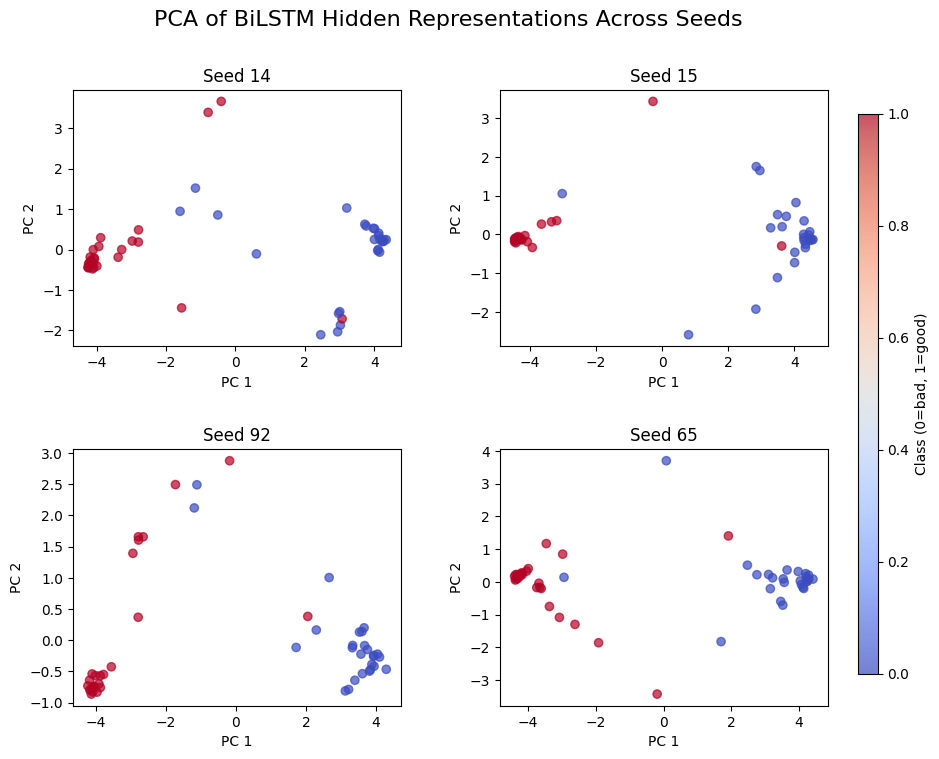

In [17]:
from sklearn.decomposition import PCA
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
import numpy as np

# Only use 4 seeds
seeds_subset = seeds[:4]

# 2x2 PCA plot
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle("PCA of BiLSTM Hidden Representations Across Seeds", fontsize=16)

for i, seed in enumerate(seeds_subset):
    print(f"\n🧪 Seed {seed}")
    set_seed(seed)

    # Prepare data
    X_train, X_test, y_train, y_test = train_test_split(
        X_data, y_labels, test_size=0.2, stratify=y_labels, random_state=seed
    )
    augmenter = Augmenter(noise_std=0.05, noise_n=2, mirror=False)
    X_train, y_train = augmenter.augment(X_train, y_train, base_seed=seed)
    y_train = y_train.reshape(-1, 1).astype(np.float32)
    y_test = y_test.reshape(-1, 1).astype(np.float32)

    # Build + train model
    model_builder = make_model_builder(input_shape=(X_train.shape[1], X_train.shape[2]))
    final_model = model_builder(lstm_units=96, dropout_rate=0.3, learning_rate=0.0003)
    final_model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=0)

    # Extract hidden features
    intermediate_model = Model(inputs=final_model.input, outputs=final_model.get_layer(index=-2).output)
    hidden_features = intermediate_model.predict(X_test)

    # PCA
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(hidden_features)

    # Plot in grid
    row, col = divmod(i, 2)
    ax = axes[row][col]
    scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=y_test.flatten(), cmap="coolwarm", alpha=0.7)
    ax.set_title(f"Seed {seed}")
    ax.set_xlabel("PC 1")
    ax.set_ylabel("PC 2")

# Reserve space and place shared colorbar
fig.subplots_adjust(right=0.88, hspace=0.4, wspace=0.3)  # room for colorbar + spacing
cbar_ax = fig.add_axes([0.91, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
fig.colorbar(scatter, cax=cbar_ax, label="Class (0=bad, 1=good)")

plt.show()
